# Bitcoin Heist: Ransomware Detection on Transaction Graphs
**Authors:** Théo MICHEL & Théo RICO — ISAE-SUPAERO

---

## 1. Problem Formulation & Hypotheses
* **Context & AI / ML Framing:** In decentralized ecosystems, cybercriminals use ransomware to extort cryptocurrencies. We frame this challenge as a supervised **Machine Learning (ML)** anomaly detection task within the broader scope of applied **Artificial Intelligence (AI)**.
* **Objective:** Predict whether a given Bitcoin address is benign (`white`) or associated with ransomware activity based on transactional graph aggregates.
* **Domain Hypotheses:**
  - Illicit actors introduce structural topological patterns: high reuse/looping (`looped`), specific splitting/merging behavior (`neighbors`, `weight`), and fast transfer paths (`length`).
  - While raw transactions form dynamic graphs suitable for **Deep Learning (DL)** (e.g., Graph Neural Networks), tree-based gradient boosting models trained on tabular graph-extracted **features** provide state-of-the-art predictive performance, fast inference, and clear interpretability.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_auc_score, average_precision_score
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

# Définition des types pour économiser la mémoire vive
dtypes = {
    'address': 'string',
    'year': 'int16',
    'day': 'int16',
    'length': 'int32',
    'weight': 'float32',
    'count': 'int32',
    'looped': 'int32',
    'neighbors': 'int32',
    'income': 'float64',
    'label': 'category'
}

df = pd.read_csv("BitcoinHeistData.csv", dtype=dtypes)

print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"RAM Usage: {df.memory_usage().sum() / (1024**2):.2f} MB")
df.head() 
# sort les 5 premières lignes du dataset pour avoir un aperçu des données | df.head(n) pour sortir les n premières,
# df.tail(n) pour sortir les n dernières, df.sample(n) pour sortir n lignes aléatoires

Dataset shape: 2,916,697 rows, 10 columns
RAM Usage: 114.05 MB


,address,year,day,length,weight,count,looped,neighbors,income,label
0,111K8kZAEnJg245r2cM6y9zgJGHZtJPy6,2017,11,18,0.008333,1,0,2,100050000.0,princetonCerber
1,1123pJv8jzeFQaCV4w644pzQJzVWay2zcA,2016,132,44,0.000244,1,0,1,100000000.0,princetonLocky
2,112536im7hy6wtKbpH1qYDWtTyMRAcA2p7,2016,246,0,1.000000,1,0,2,200000000.0,princetonCerber
3,1126eDRw2wqSkWosjTCre8cjjQW8sSeWH7,2016,322,72,0.003906,1,0,2,71200000.0,princetonCerber
4,1129TSjKtx65E35GiUo4AYVeyo48twbrGX,2016,238,144,0.072848,456,0,1,200000000.0,princetonLocky


---
## 2. Step 1: Exploration Phase (EDA)
We inspect dataset integrity, evaluate class balance, evaluate linear correlations between topological features, and analyze feature separability and skewness.

### 2.1 Intégrité des Données & Déséquilibre de Classe
Avant toute modélisation, nous vérifions la complétude des observations (recherche de valeurs manquantes) et analysons la distribution de la variable cible `label` après binarisation (`white` vs rançongiciels).

Total des valeurs manquantes dans le dataset : 0

Distribution des classes :
- Saines (White)   : 2,875,284 (98.58%)
- Ransomwares      : 41,413 (1.42%)


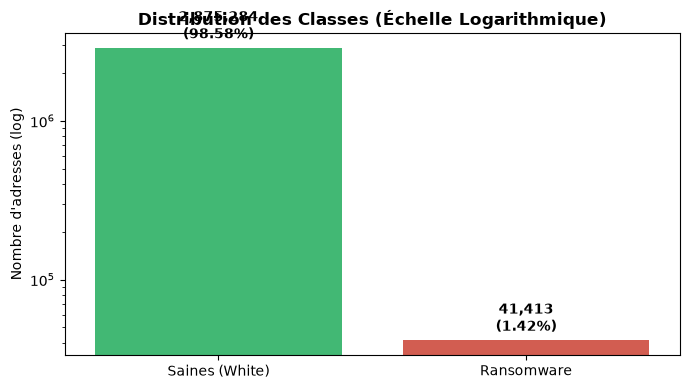

In [10]:
# 1. Vérification de l'intégrité des données
missing_total = df.isnull().sum().sum()
print(f"Total des valeurs manquantes dans le dataset : {missing_total}")

# 2. Binarisation de la cible (0 = Saine / White, 1 = Ransomware)
df['is_ransomware'] = (df['label'] != 'white').astype(int)

counts = df['is_ransomware'].value_counts()
proportions = df['is_ransomware'].value_counts(normalize=True) * 100

print(f"\nDistribution des classes :")
print(f"- Saines (White)   : {counts[0]:,} ({proportions[0]:.2f}%)")
print(f"- Ransomwares      : {counts[1]:,} ({proportions[1]:.2f}%)")

# Visualisation du déséquilibre de classe en échelle logarithmique
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    x=['Saines (White)', 'Ransomware'], 
    y=counts.values, 
    hue=['Saines (White)', 'Ransomware'], 
    palette=['#2ecc71', '#e74c3c'], 
    legend=False
)
ax.set_yscale('log')
ax.set_title("Distribution des Classes (Échelle Logarithmique)", fontsize=12, fontweight='bold')
ax.set_ylabel("Nombre d'adresses (log)")

for i, v in enumerate(counts.values):
    ax.text(i, v * 1.15, f"{v:,}\n({proportions[i]:.2f}%)", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

* **Constat :** Le jeu de données ne présente aucune valeur manquante, ce qui évite toute étape d'imputation artificielle. Cependant, l'asymétrie est extrême : environ 2,87 millions d'adresses légitimes pour 41 413 adresses malveillantes (1,42 %).
* **Impact sur le choix des métriques :** L'**Accuracy** globale est inexploitable. Un prédicteur naïf affectant systématiquement la classe majoritaire atteindrait 98,58 % d'exactitude apparente sans détecter un seul cybercriminel.
* **Conséquence méthodologique :** L'évaluation privilégiera la **Precision-Recall AUC (PR-AUC)**, le **Recall** et le **F1-score**, combinés à un coefficient de surpondération de la classe positive (`scale_pos_weight`) lors de l'apprentissage.

### 2.2 Analyse des Dépendances Linéaires & Corrélations
Nous étudions la matrice de **Correlation** de Pearson entre les métriques topologiques de graphe (`length`, `weight`, `count`, `looped`, `neighbors`, `income`) et la cible binaire afin de détecter d'éventuelles multicolinéarités.

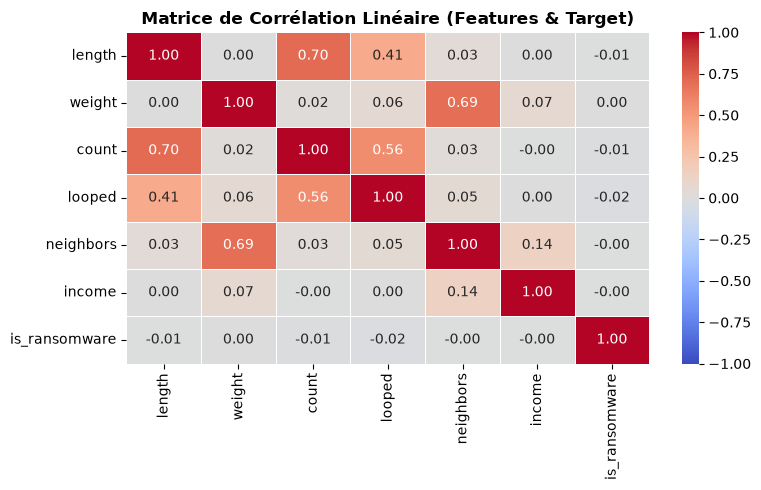

In [11]:
features_num = ['length', 'weight', 'count', 'looped', 'neighbors', 'income']

plt.figure(figsize=(8, 5))
corr_matrix = df[features_num + ['is_ransomware']].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)
plt.title("Matrice de Corrélation Linéaire (Features & Target)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

* **Constat :** 
  - On constate des corrélations linéaires marquées entre certaines **Features** issues du graphe de transactions, particulièrement entre `length` et `count` ($r = 0.70$) ainsi qu'entre `weight` et `neighbors` ($r = 0.69$).
  - La corrélation linéaire directe entre chaque feature isolée et `is_ransomware` est quasi nulle ($\approx -0.01$ à $0.00$).
* **Justification algorithmique :** L'absence de corrélation linéaire simple rend les séparateurs linéaires basiques inadaptés sans projection complexe. En revanche, les algorithmes basés sur des arbres de décision (Gradient Boosting) gèrent naturellement la non-linéarité par partitionnement récursif et restent totalement insensibles à la colinéarité entre variables prédictives.

### 2.3 Analyse de Séparabilité, Dispersion & Valeurs Extrêmes
Les transactions financières sur la blockchain présentent souvent des dynamiques exponentielles. Nous visualisons ici la distribution de chaque variable transformée en échelle logarithmique `np.log1p` pour chaque classe via des boxplots.

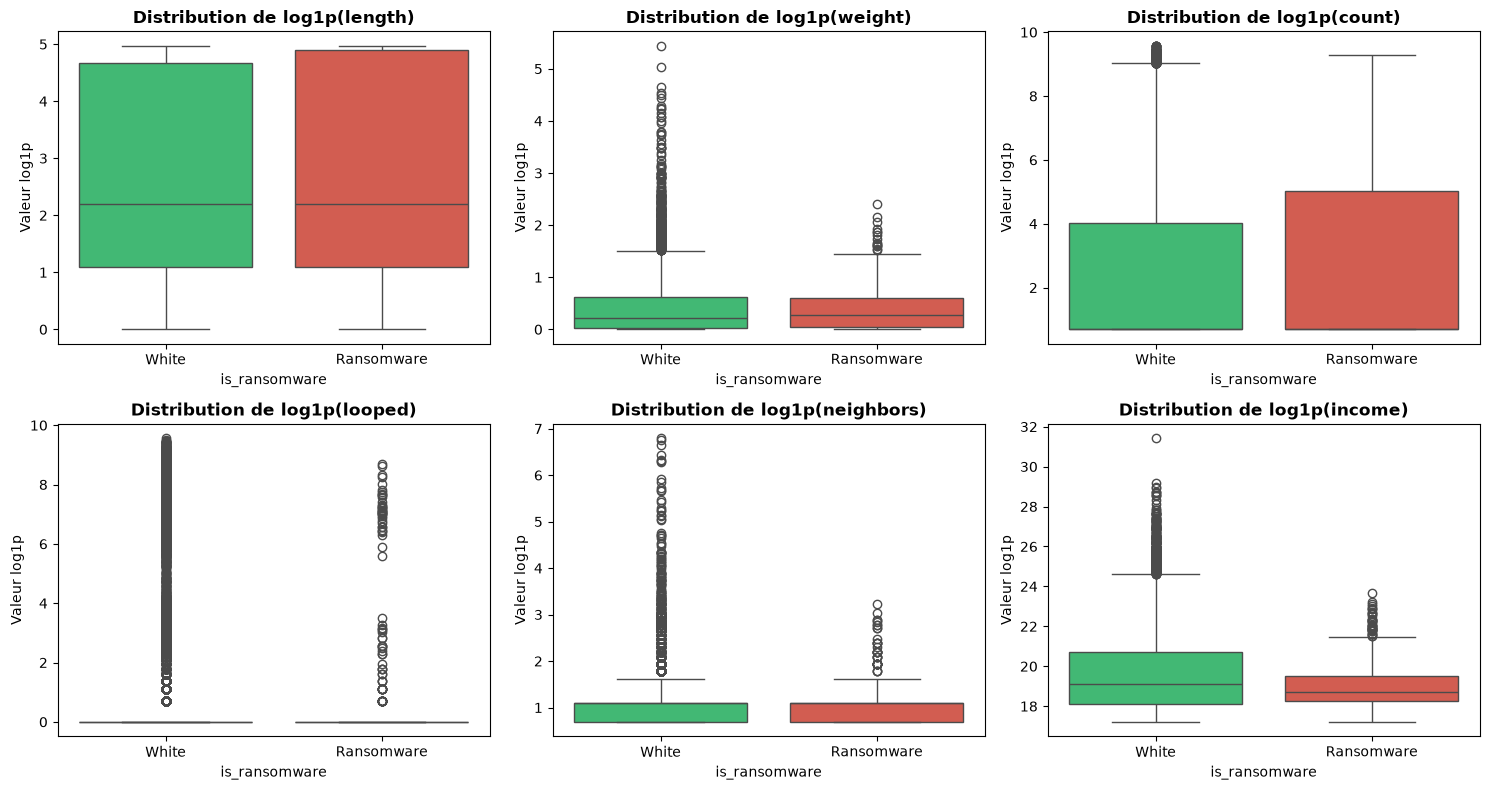

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Échantillon stratifié représentatif pour maintenir un rendu réactif
sample_df = df.sample(50000, random_state=42)

for i, col in enumerate(features_num):
    sns.boxplot(
        x='is_ransomware', 
        y=np.log1p(sample_df[col]), 
        data=sample_df, 
        ax=axes[i], 
        hue='is_ransomware',
        palette=['#2ecc71', '#e74c3c'],
        legend=False
    )
    axes[i].set_title(f"Distribution de log1p({col})", fontweight='bold')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['White', 'Ransomware'])
    axes[i].set_ylabel("Valeur log1p")

plt.tight_layout()
plt.show()

* **Constat :** 
  - Les distributions brutes présentent de très fortes queues de distribution (*heavy tails*) avec des valeurs extrêmes considérables sur `income`, `looped` et `neighbors`.
  - La variable `count` fait ressortir une médiane nettement plus élevée chez les rançongiciels, soulignant une concentration d'opérations groupées lors des mécanismes de collecte ou de blanchiment.
* **Conséquence pour le Feature Engineering :** Une standardisation standard ($z$-score) serait neutralisée par l'ampleur des outliers. L'application systématique d'une transformation logarithmique `np.log1p(x)` s'impose pour stabiliser la variance des prédicteurs et prévenir l'**Overfitting** induit par des montants hors normes.

---